In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_df = pd.read_csv("./sales_data-2.csv")
customers_df = pd.read_csv("./customers_data.csv")

In [3]:
print("Sales dataset loaded:", sales_df.shape)
print("Customer dataset loaded:", customers_df.shape)

Sales dataset loaded: (2500, 9)
Customer dataset loaded: (1000, 6)


In [4]:
print("SALES DATA")
display(sales_df.head())

print("\nCUSTOMER DATA")
display(customers_df.head())

SALES DATA


,Transaction_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Payment_Method
0,f3daa723,2024-01-01 00:00:00,0583d6,Clothing,Sofa,4,412,1648,Credit Card
1,9e5061b5,2024-01-01 01:00:00,4c0f1b,Home Decor,Novel,3,201,603,Cash
2,a5da9276,2024-01-01 02:00:00,00b49a,Home Decor,T-Shirt,1,480,480,Credit Card
3,b72e138c,2024-01-01 03:00:00,e093b6,Books,Laptop,2,16,32,Credit Card
4,c6010e46,2024-01-01 04:00:00,7c817c,Home Decor,Laptop,4,342,1368,Debit Card



CUSTOMER DATA


,Customer_ID,Name,Age,Gender,Location,Total_Spent
0,3c4189,Kevin Hanna,22,Female,Los Angeles,4179
1,912124,Marisa Sullivan,60,Other,Los Angeles,1683
2,3babe0,Shawn Gonzales,45,Female,Houston,358
3,b198b8,Charles Mejia,68,Male,New York,1541
4,2156a9,Kimberly Francis,43,Female,Los Angeles,2911


In [5]:
print("Sales columns:")
print(sales_df.columns.tolist())

print("\nCustomer columns:")
print(customers_df.columns.tolist())

Sales columns:
['Transaction_ID', 'Date', 'Customer_ID', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Total_Amount', 'Payment_Method']

Customer columns:
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Total_Spent']


In [6]:
print("SALES DATA INFO")
sales_df.info()

print("\nCUSTOMER DATA INFO")
customers_df.info()

SALES DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction_ID    2500 non-null   str  
 1   Date              2500 non-null   str  
 2   Customer_ID       2500 non-null   str  
 3   Product_Category  2500 non-null   str  
 4   Product_Name      2500 non-null   str  
 5   Quantity          2500 non-null   int64
 6   Unit_Price        2500 non-null   int64
 7   Total_Amount      2500 non-null   int64
 8   Payment_Method    2500 non-null   str  
dtypes: int64(3), str(6)
memory usage: 175.9 KB

CUSTOMER DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Customer_ID  1000 non-null   str  
 1   Name         1000 non-null   str  
 2   Age          1000 non-null   int64
 3   Gender       1000 non-null 

In [7]:
print("Missing values in Sales dataset:")
print(sales_df.isnull().sum())

print("\nMissing values in Customer dataset:")
print(customers_df.isnull().sum())

Missing values in Sales dataset:
Transaction_ID      0
Date                0
Customer_ID         0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Total_Amount        0
Payment_Method      0
dtype: int64

Missing values in Customer dataset:
Customer_ID    0
Name           0
Age            0
Gender         0
Location       0
Total_Spent    0
dtype: int64


In [8]:
print("Duplicate rows in Sales dataset:",
      sales_df.duplicated().sum())

print("Duplicate rows in Customer dataset:",
      customers_df.duplicated().sum())

Duplicate rows in Sales dataset: 0
Duplicate rows in Customer dataset: 0


In [9]:
print("Sales records:", len(sales_df))
print("Unique Transaction_IDs:", sales_df["Transaction_ID"].nunique())

print("\nCustomer records:", len(customers_df))
print("Unique Customer_IDs:", customers_df["Customer_ID"].nunique())

Sales records: 2500
Unique Transaction_IDs: 2500

Customer records: 1000
Unique Customer_IDs: 1000


In [10]:
print("Duplicate Transaction_IDs:")
print(sales_df["Transaction_ID"].value_counts()
      .loc[lambda x: x > 1])

print("\nDuplicate Customer_IDs:")
print(customers_df["Customer_ID"].value_counts()
      .loc[lambda x: x > 1])

Duplicate Transaction_IDs:
Series([], Name: count, dtype: int64)

Duplicate Customer_IDs:
Series([], Name: count, dtype: int64)


In [11]:
# Validate customer ID
sales_customer_ids = set(sales_df["Customer_ID"].dropna().unique())
customer_master_ids = set(customers_df["Customer_ID"].dropna().unique())


In [12]:

# And OverLap
matched_ids = sales_customer_ids.intersection(customer_master_ids)

sales_only_ids = sales_customer_ids - customer_master_ids
customer_only_ids = customer_master_ids - sales_customer_ids

print("Unique Customer IDs in sales:", len(sales_customer_ids))
print("Unique Customer IDs in customer data:", len(customer_master_ids))
print("Matching Customer IDs:", len(matched_ids))
print("Sales IDs not found in customer data:", len(sales_only_ids))
print("Customer IDs not found in sales:", len(customer_only_ids))

Unique Customer IDs in sales: 920
Unique Customer IDs in customer data: 1000
Matching Customer IDs: 0
Sales IDs not found in customer data: 920
Customer IDs not found in sales: 1000


In [13]:
print("Sales Customer_ID examples:")
print(sales_df["Customer_ID"].head(10).tolist())

print("\nCustomer dataset Customer_ID examples:")
print(customers_df["Customer_ID"].head(10).tolist())

print("\nSales Customer_ID lengths:")
print(sales_df["Customer_ID"].astype(str).str.len().value_counts().sort_index())

print("\nCustomer dataset Customer_ID lengths:")
print(customers_df["Customer_ID"].astype(str).str.len().value_counts().sort_index())

Sales Customer_ID examples:
['0583d6', '4c0f1b', '00b49a', 'e093b6', '7c817c', 'aaeb81', 'b1a4f4', '4ddebc', '8215fb', 'deb177']

Customer dataset Customer_ID examples:
['3c4189', '912124', '3babe0', 'b198b8', '2156a9', '6655ea', '6790f4', 'e76cec', '2b401b', 'f694e2']

Sales Customer_ID lengths:
Customer_ID
6    2500
Name: count, dtype: int64

Customer dataset Customer_ID lengths:
Customer_ID
6    1000
Name: count, dtype: int64


In [14]:
print("Sales Customer_ID data type:", sales_df["Customer_ID"].dtype)
print("Customer Customer_ID data type:", customers_df["Customer_ID"].dtype)

Sales Customer_ID data type: str
Customer Customer_ID data type: str


In [15]:
print("\nSales Customer_ID sample:")
print(sales_df["Customer_ID"].drop_duplicates().head(20).tolist())

print("\nCustomer Customer_ID sample:")
print(customers_df["Customer_ID"].drop_duplicates().head(20).tolist())


Sales Customer_ID sample:
['0583d6', '4c0f1b', '00b49a', 'e093b6', '7c817c', 'aaeb81', 'b1a4f4', '4ddebc', '8215fb', 'deb177', '59fe4a', 'f59c2a', 'f415cd', '0a16fe', 'c5940a', '0ae342', 'c984e3', '197942', 'e15d65', '2a6646']

Customer Customer_ID sample:
['3c4189', '912124', '3babe0', 'b198b8', '2156a9', '6655ea', '6790f4', 'e76cec', '2b401b', 'f694e2', 'fd0c3f', 'faf7d8', '20344d', 'e2a722', 'd0975b', '4c01ac', '7c7355', 'be9cd9', '1cf8df', '7912f7']


## Validate Sales Calculations

In [16]:
# Calculate expected transaction amount
sales_df["Calculated_Amount"] = (
    sales_df["Quantity"] * sales_df["Unit_Price"]
)

# Compare calculated amount with recorded amount
sales_df["Amount_Match"] = (
    sales_df["Calculated_Amount"] == sales_df["Total_Amount"]
)

print("Matching amount records:",
      sales_df["Amount_Match"].sum())

print("Non-matching amount records:",
      (~sales_df["Amount_Match"]).sum())

Matching amount records: 2500
Non-matching amount records: 0


In [17]:
mismatches = sales_df[~sales_df["Amount_Match"]]

display(
    mismatches[
        [
            "Transaction_ID",
            "Quantity",
            "Unit_Price",
            "Total_Amount",
            "Calculated_Amount"
        ]
    ].head(20)
)

,Transaction_ID,Quantity,Unit_Price,Total_Amount,Calculated_Amount


In [18]:
# Validate numeric values
print("Sales numeric summary:")
display(
    sales_df[
        ["Quantity", "Unit_Price", "Total_Amount"]
    ].describe()
)

Sales numeric summary:


,Quantity,Unit_Price,Total_Amount
count,2500.000000,2500.000000,2500.000000
mean,2.524800,254.872000,645.176000
std,1.130087,142.714771,491.167374
min,1.000000,10.000000,10.000000
25%,2.000000,129.000000,249.000000
50%,3.000000,259.000000,491.000000
75%,4.000000,379.250000,950.000000
max,4.000000,499.000000,1996.000000


In [19]:
print("Customer numeric summary:")
display(
    customers_df[
        ["Age", "Total_Spent"]
    ].describe()
)

Customer numeric summary:


,Age,Total_Spent
count,1000.00000,1000.000000
mean,43.57200,2558.625000
std,14.88329,1438.654573
min,18.00000,101.000000
25%,31.00000,1255.750000
50%,43.00000,2536.000000
75%,56.00000,3840.250000
max,69.00000,4996.000000


In [20]:
# Validate the Date column
print(sales_df["Date"].head())
print("\nCurrent data type:", sales_df["Date"].dtype)

0    2024-01-01 00:00:00
1    2024-01-01 01:00:00
2    2024-01-01 02:00:00
3    2024-01-01 03:00:00
4    2024-01-01 04:00:00
Name: Date, dtype: str

Current data type: str


In [21]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"])

In [22]:
print("New data type:", sales_df["Date"].dtype)

print("Minimum date:", sales_df["Date"].min())
print("Maximum date:", sales_df["Date"].max())

New data type: datetime64[us]
Minimum date: 2024-01-01 00:00:00
Maximum date: 2024-04-14 03:00:00


In [23]:
# Check categorical values
print("Product Categories:")
print(sales_df["Product_Category"].value_counts())

print("\nPayment Methods:")
print(sales_df["Payment_Method"].value_counts())

print("\nProduct Count:")
print(sales_df["Product_Name"].nunique())

print("\nCustomer Gender:")
print(customers_df["Gender"].value_counts())

print("\nCustomer Locations:")
print(customers_df["Location"].value_counts())

Product Categories:
Product_Category
Home Decor     518
Electronics    508
Clothing       500
Books          495
Beauty         479
Name: count, dtype: int64

Payment Methods:
Payment_Method
UPI            640
Cash           631
Credit Card    623
Debit Card     606
Name: count, dtype: int64

Product Count:
5

Customer Gender:
Gender
Female    335
Other     335
Male      330
Name: count, dtype: int64

Customer Locations:
Location
Chicago        209
New York       207
Houston        199
Los Angeles    197
Miami          188
Name: count, dtype: int64


In [24]:
# Drop temp Colns
sales_df.drop(
    columns=["Calculated_Amount", "Amount_Match"],
    inplace=True
)

print(sales_df.columns.tolist())

['Transaction_ID', 'Date', 'Customer_ID', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Total_Amount', 'Payment_Method']


In [25]:
sales_clean = sales_df.copy()
customers_clean = customers_df.copy()

print("Sales clean shape:", sales_clean.shape)
print("Customer clean shape:", customers_clean.shape)

Sales clean shape: (2500, 9)
Customer clean shape: (1000, 6)


In [ ]:
sales_clean.to_csv("sales_clean.csv", index=False)
customers_clean.to_csv("customers_clean.csv", index=False)

## EDA

In [26]:
total_revenue = sales_clean["Total_Amount"].sum()
total_transactions = sales_clean["Transaction_ID"].nunique()
total_units = sales_clean["Quantity"].sum()
average_transaction_value = total_revenue / total_transactions

print("Total Revenue:", total_revenue)
print("Total Transactions:", total_transactions)
print("Total Units Sold:", total_units)
print("Average Transaction Value:", round(average_transaction_value, 2))

Total Revenue: 1612940
Total Transactions: 2500
Total Units Sold: 6312
Average Transaction Value: 645.18


In [27]:
# Monthly Sales Trends
monthly_sales = (
    sales_clean
    .assign(Month=sales_clean["Date"].dt.to_period("M").astype(str))
    .groupby("Month")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Units=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

monthly_sales["Average_Transaction_Value"] = (
    monthly_sales["Revenue"] / monthly_sales["Transactions"]
)

monthly_sales

,Month,Transactions,Units,Revenue,Average_Transaction_Value
0,2024-01,744,1870,478627,643.315860
1,2024-02,696,1755,443457,637.150862
2,2024-03,744,1861,478836,643.596774
3,2024-04,316,826,212020,670.949367


In [28]:
monthly_sales["Revenue_MoM_%"] = (
    monthly_sales["Revenue"].pct_change() * 100
)

monthly_sales

,Month,Transactions,Units,Revenue,Average_Transaction_Value,Revenue_MoM_%
0,2024-01,744,1870,478627,643.315860,NaN
1,2024-02,696,1755,443457,637.150862,-7.348102
2,2024-03,744,1861,478836,643.596774,7.978000
3,2024-04,316,826,212020,670.949367,-55.721792


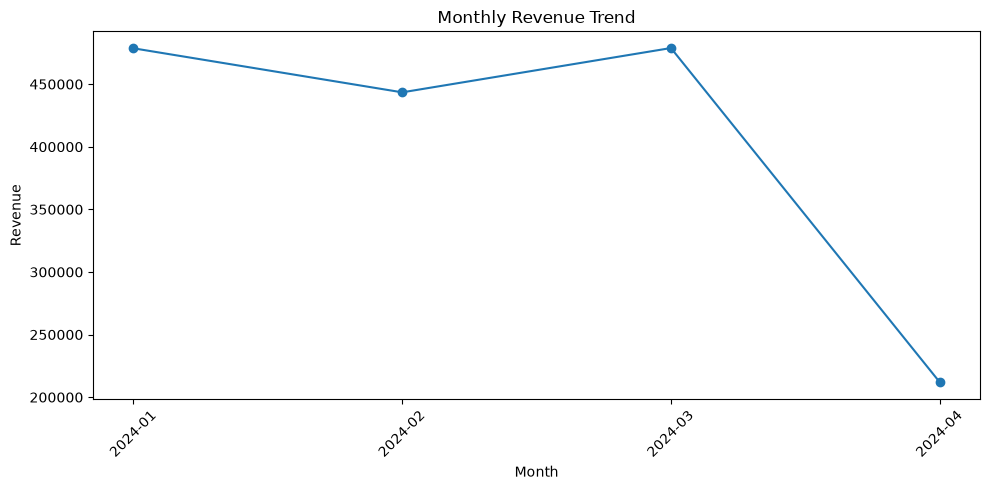

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Daily Sales Trend
daily_sales = (
    sales_clean
    .groupby(sales_clean["Date"].dt.date)
    .agg(
        Revenue=("Total_Amount", "sum"),
        Transactions=("Transaction_ID", "count"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

daily_sales.head()

,Date,Revenue,Transactions,Units
0,2024-01-01,13400,24,55
1,2024-01-02,15343,24,58
2,2024-01-03,11055,24,56
3,2024-01-04,16904,24,61
4,2024-01-05,14176,24,55


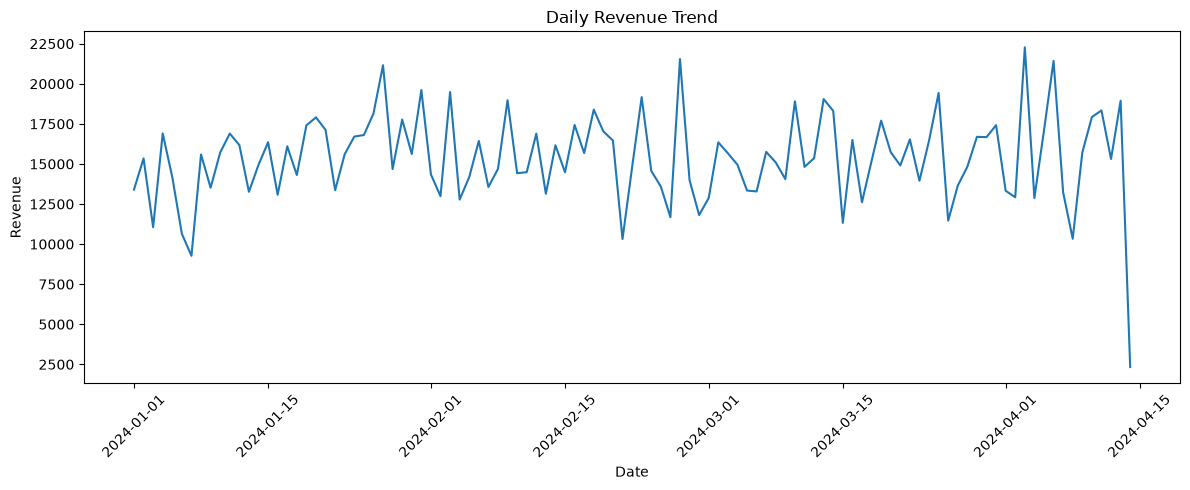

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"]
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [32]:
# Revenue by Product Category
category_sales = (
    sales_clean
    .groupby("Product_Category")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Units_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

category_sales["Revenue_Share_%"] = (
    category_sales["Revenue"]
    / category_sales["Revenue"].sum()
    * 100
)

category_sales["Average_Transaction_Value"] = (
    category_sales["Revenue"]
    / category_sales["Transactions"]
)

category_sales = category_sales.sort_values(
    "Revenue",
    ascending=False
)

category_sales

,Product_Category,Transactions,Units_Sold,Revenue,Revenue_Share_%,Average_Transaction_Value
2,Clothing,500,1287,335944,20.828053,671.888000
4,Home Decor,518,1287,330645,20.499523,638.310811
3,Electronics,508,1283,323908,20.081838,637.614173
1,Books,495,1233,313037,19.407852,632.397980
0,Beauty,479,1222,309406,19.182735,645.941545


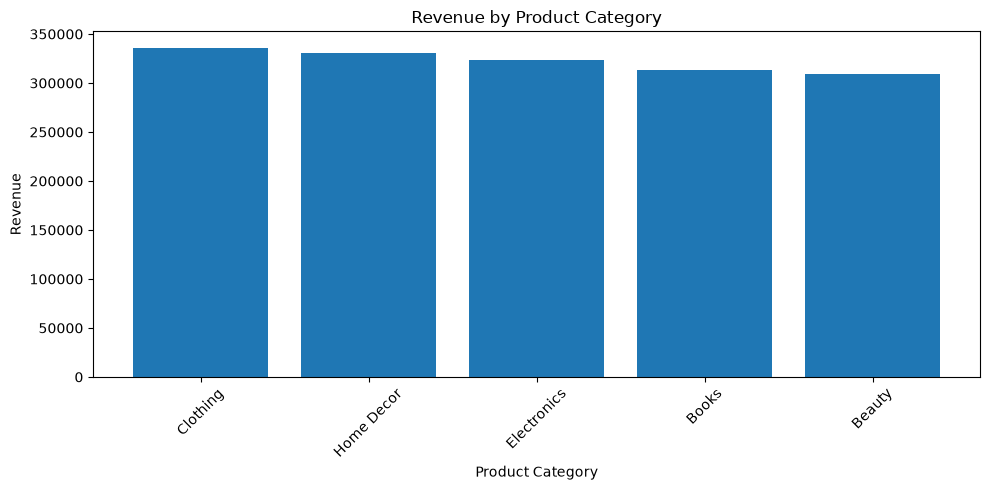

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_sales["Product_Category"],
    category_sales["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Category Units Sold
category_units = category_sales.sort_values(
    "Units_Sold",
    ascending=False
)

display(
    category_units[
        [
            "Product_Category",
            "Units_Sold",
            "Transactions",
            "Revenue",
            "Revenue_Share_%",
            "Average_Transaction_Value"
        ]
    ]
)

,Product_Category,Units_Sold,Transactions,Revenue,Revenue_Share_%,Average_Transaction_Value
2,Clothing,1287,500,335944,20.828053,671.888000
4,Home Decor,1287,518,330645,20.499523,638.310811
3,Electronics,1283,508,323908,20.081838,637.614173
1,Books,1233,495,313037,19.407852,632.397980
0,Beauty,1222,479,309406,19.182735,645.941545


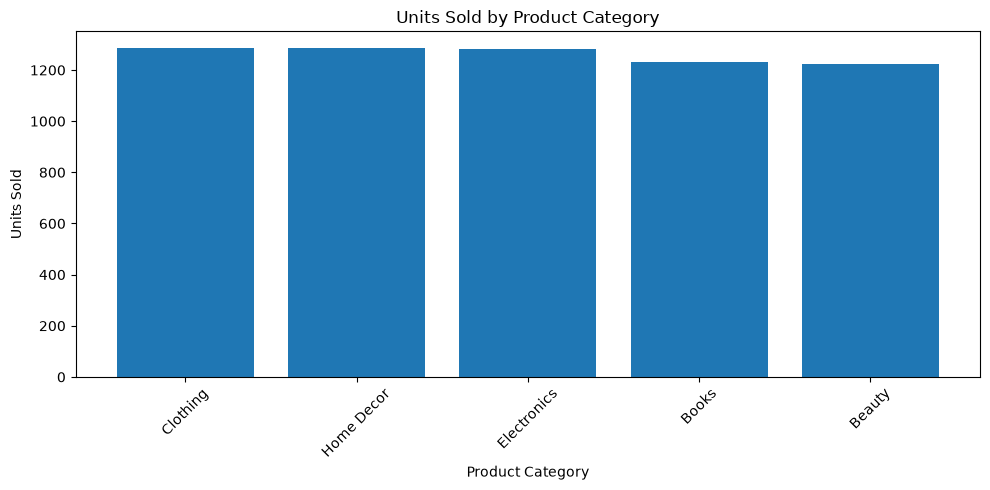

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_units["Product_Category"],
    category_units["Units_Sold"]
)

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Product Performance.
product_sales = (
    sales_clean
    .groupby("Product_Name")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Units_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

product_sales["Revenue_Share_%"] = (
    product_sales["Revenue"]
    / product_sales["Revenue"].sum()
    * 100
)

product_sales = product_sales.sort_values(
    "Revenue",
    ascending=False
)

product_sales

,Product_Name,Transactions,Units_Sold,Revenue,Revenue_Share_%
3,Sofa,530,1358,353847,21.938014
1,Lipstick,490,1268,320824,19.890634
2,Novel,513,1268,320820,19.890386
0,Laptop,488,1237,320440,19.866827
4,T-Shirt,479,1181,297009,18.414138


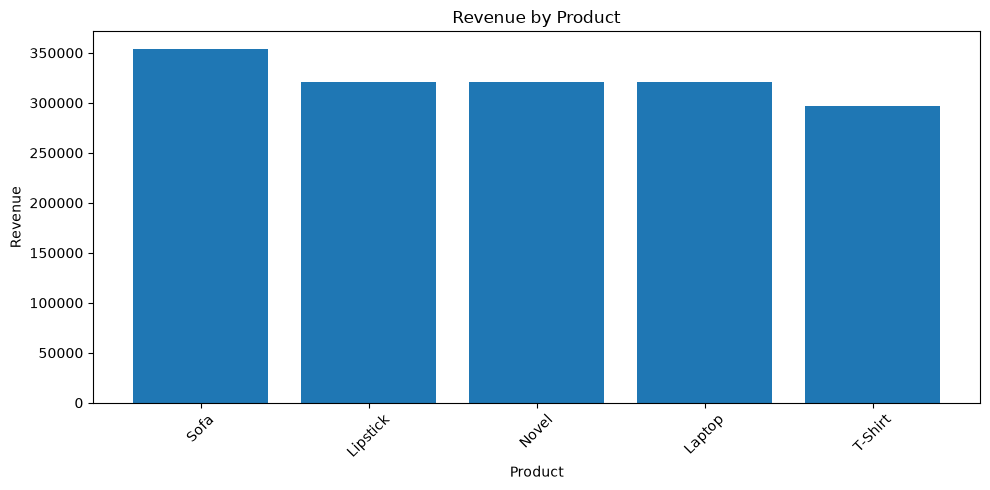

In [37]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_sales["Product_Name"],
    product_sales["Revenue"]
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

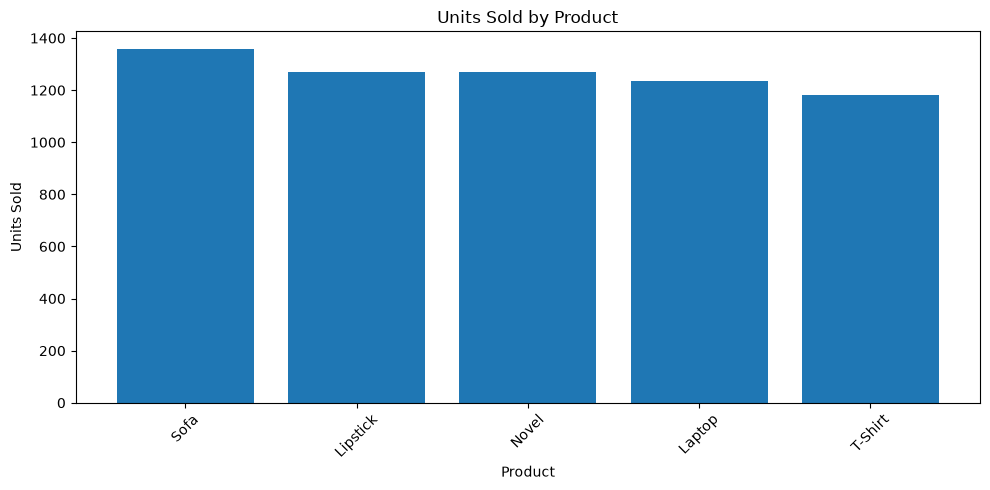

In [39]:
product_units = product_sales.sort_values(
    "Units_Sold",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    product_units["Product_Name"],
    product_units["Units_Sold"]
)

plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# Save Tables
category_sales.to_csv(
    "category_sales_analysis.csv",
    index=False
)

product_sales.to_csv(
    "product_sales_analysis.csv",
    index=False
)

monthly_sales.to_csv(
    "monthly_sales_analysis.csv",
    index=False
)

In [41]:
payment_analysis = (
    sales_clean
    .groupby("Payment_Method")
    .agg(
        Transactions=("Transaction_ID", "count"),
        Units_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

payment_analysis["Revenue_Share_%"] = (
    payment_analysis["Revenue"]
    / payment_analysis["Revenue"].sum()
    * 100
)

payment_analysis["Average_Transaction_Value"] = (
    payment_analysis["Revenue"]
    / payment_analysis["Transactions"]
)

payment_analysis = payment_analysis.sort_values(
    "Revenue",
    ascending=False
)

payment_analysis

,Payment_Method,Transactions,Units_Sold,Revenue,Revenue_Share_%,Average_Transaction_Value
0,Cash,631,1594,409899,25.413159,649.602219
3,UPI,640,1620,409714,25.401689,640.178125
2,Debit Card,606,1575,399212,24.750580,658.765677
1,Credit Card,623,1523,394115,24.434573,632.608347


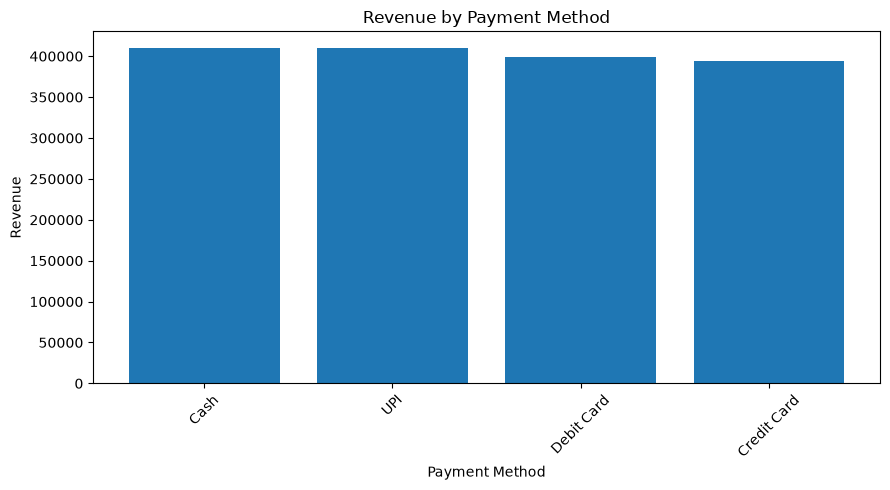

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_analysis["Payment_Method"],
    payment_analysis["Revenue"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

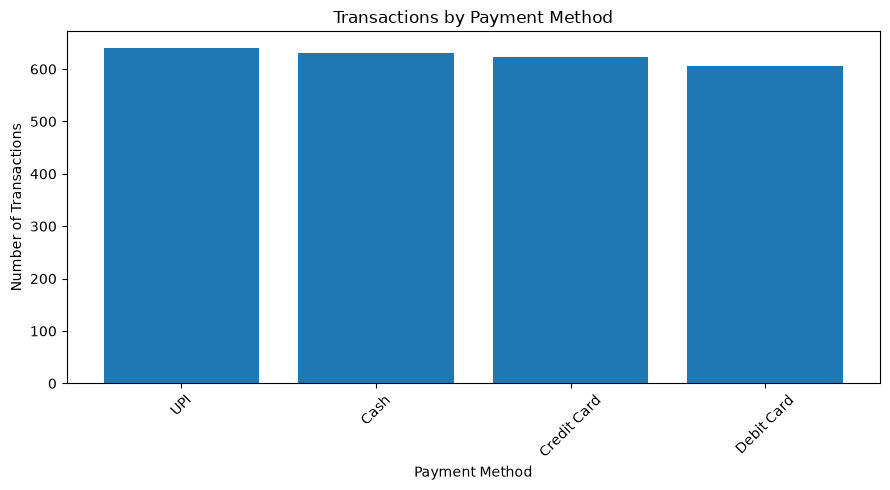

In [43]:
payment_usage = payment_analysis.sort_values(
    "Transactions",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    payment_usage["Payment_Method"],
    payment_usage["Transactions"]
)

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
payment_atv = payment_analysis.sort_values(
    "Average_Transaction_Value",
    ascending=False
)

display(
    payment_atv[
        [
            "Payment_Method",
            "Transactions",
            "Revenue",
            "Revenue_Share_%",
            "Average_Transaction_Value"
        ]
    ]
)

,Payment_Method,Transactions,Revenue,Revenue_Share_%,Average_Transaction_Value
2,Debit Card,606,399212,24.750580,658.765677
0,Cash,631,409899,25.413159,649.602219
3,UPI,640,409714,25.401689,640.178125
1,Credit Card,623,394115,24.434573,632.608347


In [45]:
payment_analysis.to_csv(
    "payment_method_analysis.csv",
    index=False
)

In [46]:
sales_clean.to_csv(
    "TrendMart_Sales_PowerBI.csv",
    index=False
)

In [47]:
customers_clean.to_csv(
    "TrendMart_Customers_PowerBI.csv",
    index=False
)